# Excess heat factor: local time zone support

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import numpy as np

from earthkit.meteo.thermo import excess_heat

## ERA5: retrieve five days of hourly global 2 m temperatures

In [2]:
data = ekd.from_source(
    "cds",
    dataset="reanalysis-era5-single-levels",
    request={
        "product_type": ["reanalysis"],
        "variable": ["2m_temperature"],
        "year": ["2025"],
        "month": ["07"],
        "day": ["01", "02", "03", "04", "05"],
        "time": [
            "00:00",
            "01:00",
            "02:00",
            "03:00",
            "04:00",
            "05:00",
            "06:00",
            "07:00",
            "08:00",
            "09:00",
            "10:00",
            "11:00",
            "12:00",
            "13:00",
            "14:00",
            "15:00",
            "16:00",
            "17:00",
            "18:00",
            "19:00",
            "20:00",
            "21:00",
            "22:00",
            "23:00",
        ],
        "grid": [0.5, 0.5],
        "data_format": "grib",
        "download_format": "unarchived",
    },
)

2026-07-09 14:26:58,099 INFO Request ID is 0cf4a367-a496-4d2f-bb73-2420cf0127e0
2026-07-09 14:26:58,164 INFO status has been updated to accepted
2026-07-09 14:27:24,167 INFO status has been updated to running
2026-07-09 14:27:35,607 INFO status has been updated to successful


In [4]:
t2m = data.to_xarray(time_dims=["valid_time"])["2t"]
t2m

<xarray.DataArray '2t' (valid_time: 120, latitude: 361, longitude: 720)> Size: 250MB
[31190400 values with dtype=float64]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2025-07-01 ... 2025-07-05T23...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          kelvin
    level_type:     surface
    _earthkit:      {"message": {"__bytes_b64__": "R1JJQgAAbAEAADSAYpH/gKcBAA...

## Defining time zones

We assign one of 24 time zones with shifts from UTC+11 to UTC-12 to each longitude.
The UTC+0 time zone is centred at the prime meridian.

In [5]:
def local_time_shift_h(lons, lon0=0.0, width=np.timedelta64(1, "h")):
    n_timezones = np.timedelta64(24, "h") / width
    assert n_timezones == int(n_timezones)
    shift = np.round((lons - lon0) / (360 / n_timezones)) * width
    # Combine -12h and +12h zones (only keep -12h)
    shift_dt = (shift + np.timedelta64(12, "h")) % np.timedelta64(24, "h") - np.timedelta64(12, "h")
    return shift_dt.drop_attrs().rename("time_shift")


def shift_day_start(shift, day_start_hour):
    """
    day_start_hour : number
        Constant offset for the start of the day in the aggregations. By
        default, the day is defined from 09:00 to 09:00. Positive offsets
        indicate a late start of the day, negative an early start. A numeric
        value is interpreted as hours.
    """
    return shift - np.timedelta64(day_start_hour, "h")

In [6]:
time_shift = local_time_shift_h(t2m["longitude"])

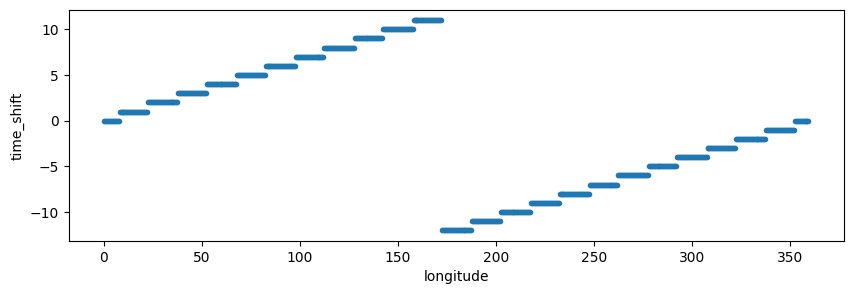

In [7]:
(time_shift / np.timedelta64(1, "h")).plot(figsize=(10, 3), marker=".", linestyle="none")

In [8]:
time_shift = shift_day_start(time_shift, day_start_hour=9)

A two-dimensional spatial field of time shifts can also be supplied to the `daily_mean_temperature` function.
There is no support for daylight savings time.

## Daily mean temperature

In [13]:
dmt = excess_heat.daily_mean_temperature(t2m, time_shift=time_shift, remove_partial_periods=True)

Plotting the daily mean temperature for the first day, we find that output is missing for timezones UTC+10 and UTC+11.
With the day starting at 9:00 local time, not enough data is available in these timezones to fill a full (local) day and daily mean temperature isn't computed.

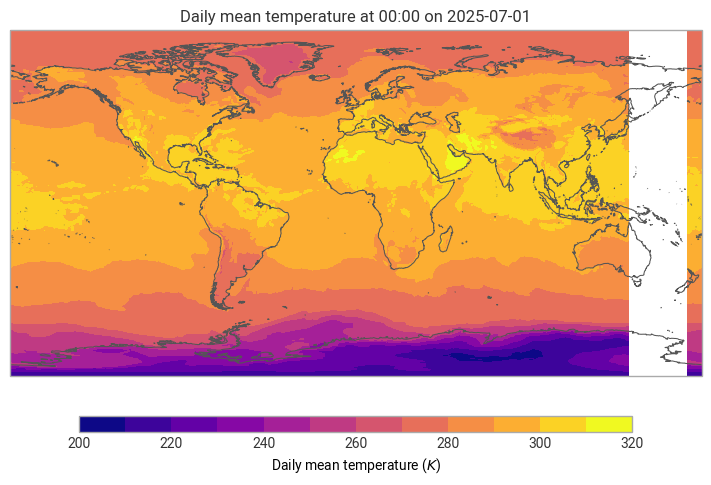

In [14]:
ekp.quickplot(dmt.isel(valid_time=0))

For the same reason, values are only available for for timezones UTC+9, UTC+10, UTC+11 on the last day:

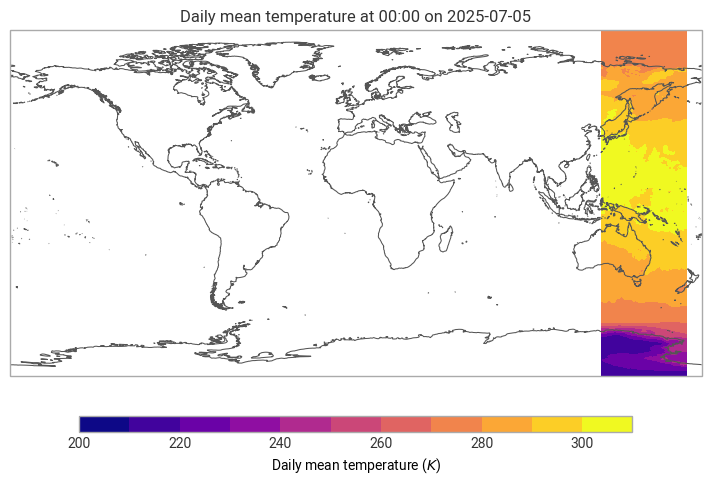

In [15]:
ekp.quickplot(dmt.isel(valid_time=-1))

The fields are complete for the intermediate timesteps, e.g.:

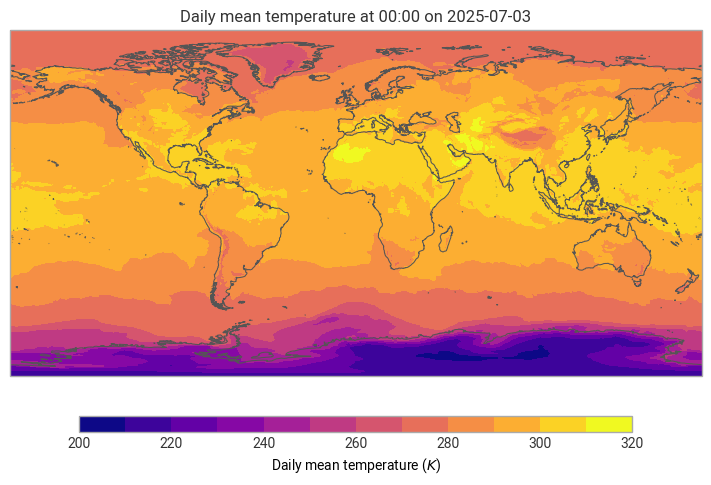

In [16]:
ekp.quickplot(dmt.isel(valid_time=2))